# 🎬 Movie Ratings Analysis

## IMDb Movie Dataset — Exploratory Data Analysis

This project analyzes movie data from 2006–2016 to explore relationships between IMDb ratings, movie runtime, genre, revenue, audience votes, and release year.

### Objectives

- Analyze the relationship between movie runtime and IMDb rating
- Compare average ratings across genres
- Examine rating trends over time
- Investigate the relationship between revenue and ratings
- Analyze the relationship between audience votes and ratings
- Analyze the relationship between audience votes and revenue
- Identify the highest-rated movies in the dataset

## 📊 Dataset Overview

The dataset contains information about 1,000 movies released between 2006 and 2016.

### Key Variables

| Variable | Description |
|---|---|
| Title | Movie title |
| Genre | Movie genre(s) |
| Year | Release year |
| Runtime (Minutes) | Movie duration |
| Rating | IMDb rating |
| Votes | Number of audience votes |
| Revenue (Millions) | Reported movie revenue |
| Metascore | Critic score |

### Data Quality

- Total records: 1,000
- Total columns: 12
- Missing Revenue values: 128
- Missing Metascore values: 64
- Complete duplicate rows: 0

Revenue and Metascore analyses use only records where the respective values are available.

In [5]:
%pip install pandas

  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
    --------------------------------------- 0.3/12.7 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.7 MB 4.0 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/12.7 MB 4.2 MB/s eta 0:00:03
   --------- ------------------------------ 3.1/12.7 MB 4.5 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.7 MB 4.8 MB/s eta 0:00:02
   ----------------- ---------------------- 5.5/12.7 MB 5.0 MB/s eta 0:00:02
   ---------------------- ----------------- 7.1/12.7 MB 5.2 MB/s eta 0:00:02
   --------------------------- ------------ 8.7/12.7 MB 5.5 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.7 MB 5.7 MB/s eta 0:00:01
   ----------------------------------- ---


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Data Loading

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("../data/IMDB-Movie-Data.csv")

In [8]:
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


### Dataset Dimensions

The dataset contains 1,000 movie records and 12 variables.

In [9]:
df.shape

(1000, 12)

### Column Information

The dataset contains movie details including genre, release year, runtime, IMDb rating, votes, revenue, and Metascore.

In [10]:
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='str')

## 2. Data Quality & Cleaning

Before performing analysis, the dataset was checked for missing values, duplicate records, data types, and unusual values.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   str    
 2   Genre               1000 non-null   str    
 3   Description         1000 non-null   str    
 4   Director            1000 non-null   str    
 5   Actors              1000 non-null   str    
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 93.9 KB


In [12]:
df.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

In [13]:
df.isnull().sum().sort_values(ascending=False)

Revenue (Millions)    128
Metascore              64
Rank                    0
Title                   0
Description             0
Genre                   0
Director                0
Actors                  0
Runtime (Minutes)       0
Year                    0
Votes                   0
Rating                  0
dtype: int64

In [14]:
revenue_df = df.dropna(subset=["Revenue (Millions)"])

In [15]:
metascore_df = df.dropna(subset=["Metascore"])

### Duplicate Records

Complete duplicate rows were checked to ensure that repeated records would not affect the analysis.

In [16]:
df.duplicated().sum()



np.int64(0)

In [17]:
df["Title"].duplicated().sum()

np.int64(1)

In [18]:
df[df["Title"].duplicated(keep=False)]

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
239,240,The Host,"Action,Adventure,Romance",When an unseen enemy threatens mankind by taki...,Andrew Niccol,"Saoirse Ronan, Max Irons, Jake Abel, Diane Kruger",2013,125,5.9,96852,26.62,35.0
632,633,The Host,"Comedy,Drama,Horror",A monster emerges from Seoul's Han River and f...,Bong Joon Ho,"Kang-ho Song, Hee-Bong Byun, Hae-il Park, Doon...",2006,120,7.0,73491,2.20,85.0


Although the title "The Host" appears twice, the records represent different movies released in different years. Therefore, they were retained.

### Missing Value Handling

The dataset contains missing values in two variables:

- Revenue (Millions): 128 missing values
- Metascore: 64 missing values

Instead of replacing missing revenue values with 0, the original dataset is preserved. For analyses involving revenue, only movies with reported revenue values are used.

Similarly, Metascore-specific analysis should use only records with available Metascore values.

In [19]:
df[["Year", "Runtime (Minutes)", "Rating", "Votes", "Revenue (Millions)", "Metascore"]].describe()

,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


### Revenue Zero-Value Check

A check was performed to identify records where reported revenue is exactly zero.

In [20]:
df[df["Revenue (Millions)"] == 0].shape

(1, 12)

In [21]:
df[df["Revenue (Millions)"] == 0][["Title", "Revenue (Millions)"]]

,Title,Revenue (Millions)
231,A Kind of Murder,0.0


In [22]:
df["Runtime (Minutes)"].corr(df["Rating"])

np.float64(0.3922142455250515)

In [24]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 2.4 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.5 MB 1.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.5 MB 1.1 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.5 MB 1.2 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.5 MB 1.3 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.5 MB 1.4 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.5 MB 1.4 MB/s eta 0:00:06
   --------- ------------------------------ 2.4/9.5 MB 1.2 MB/s eta 0:00:06
   ----------- ---------------------------- 2.6/9.5


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import matplotlib.pyplot as plt

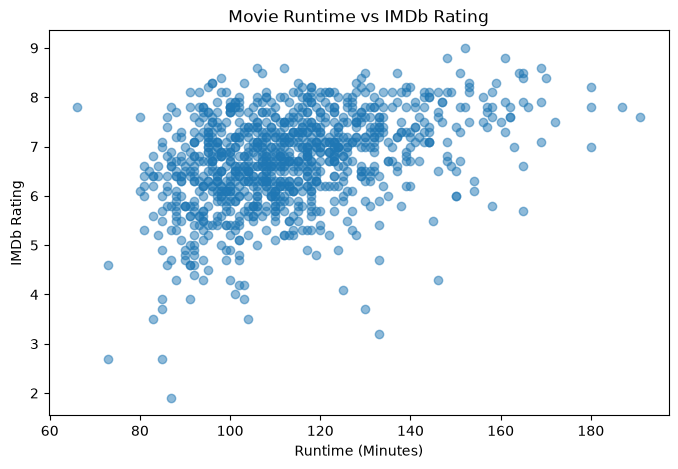

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Runtime (Minutes)"], df["Rating"], alpha=0.5)

plt.xlabel("Runtime (Minutes)")
plt.ylabel("IMDb Rating")
plt.title("Movie Runtime vs IMDb Rating")

plt.show()

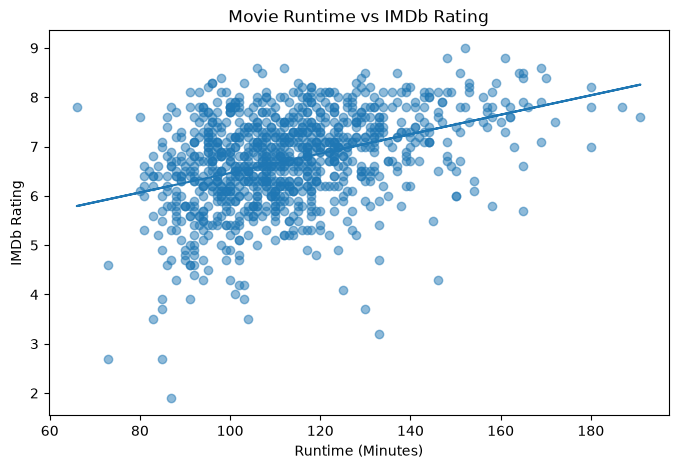

In [28]:
import numpy as np
import matplotlib.pyplot as plt

x = df["Runtime (Minutes)"]
y = df["Rating"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.5)
plt.plot(x, m*x + b)

plt.xlabel("Runtime (Minutes)")
plt.ylabel("IMDb Rating")
plt.title("Movie Runtime vs IMDb Rating")

plt.show()

In [29]:
df["Genre"].value_counts().head(15)

Genre
Action,Adventure,Sci-Fi       50
Drama                         48
Comedy,Drama,Romance          35
Comedy                        32
Drama,Romance                 31
Action,Adventure,Fantasy      27
Animation,Adventure,Comedy    27
Comedy,Drama                  27
Comedy,Romance                26
Crime,Drama,Thriller          24
Crime,Drama,Mystery           23
Action,Adventure,Drama        18
Action,Crime,Drama            17
Horror,Thriller               16
Drama,Thriller                15
Name: count, dtype: int64

In [30]:
genre_df = df.copy()

genre_df["Genre"] = genre_df["Genre"].str.split(",")

genre_df = genre_df.explode("Genre")

genre_df["Genre"] = genre_df["Genre"].str.strip()

genre_df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,Action,A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
0,1,Guardians of the Galaxy,Adventure,A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
0,1,Guardians of the Galaxy,Sci-Fi,A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,Adventure,"Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
1,2,Prometheus,Mystery,"Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0


In [31]:
genre_df["Genre"].value_counts()

Genre
Drama        513
Action       303
Comedy       279
Adventure    259
Thriller     195
Crime        150
Romance      141
Sci-Fi       120
Horror       119
Mystery      106
Fantasy      101
Biography     81
Family        51
Animation     49
History       29
Sport         18
Music         16
War           13
Western        7
Musical        5
Name: count, dtype: int64

In [32]:
genre_rating = (
    genre_df.groupby("Genre")["Rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

genre_rating

,mean,count
Genre,,
War,7.353846,13
Animation,7.324490,49
Biography,7.290123,81
History,7.127586,29
Music,7.075000,16
Sport,7.011111,18
Drama,6.953801,513
Musical,6.940000,5
Mystery,6.886792,106


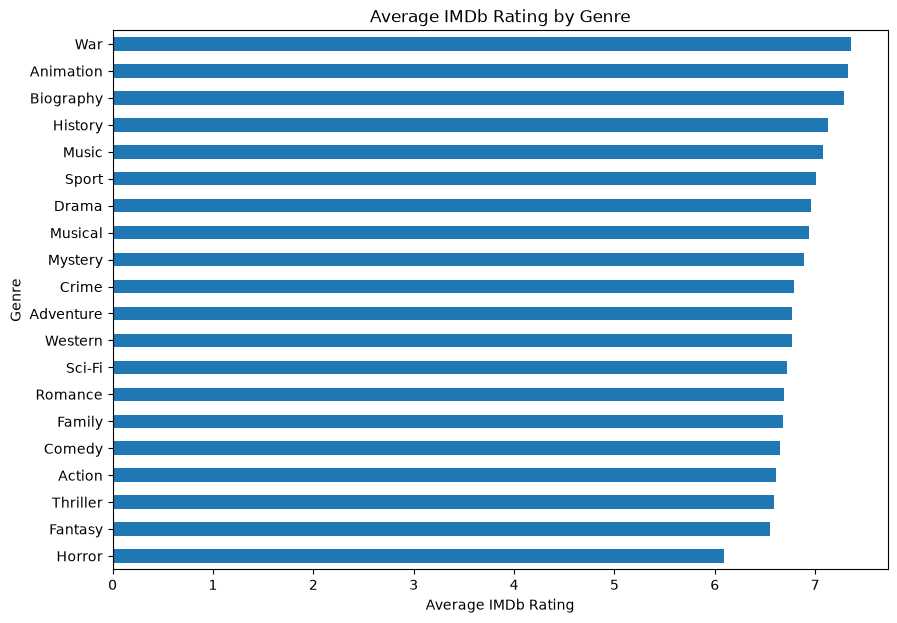

In [33]:
genre_rating["mean"].sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")
plt.title("Average IMDb Rating by Genre")

plt.show()

In [34]:
yearly_rating = (
    df.groupby("Year")["Rating"]
    .mean()
    .sort_index()
)

yearly_rating

Year
2006    7.125000
2007    7.133962
2008    6.784615
2009    6.960784
2010    6.826667
2011    6.838095
2012    6.925000
2013    6.812088
2014    6.837755
2015    6.602362
2016    6.436700
Name: Rating, dtype: float64

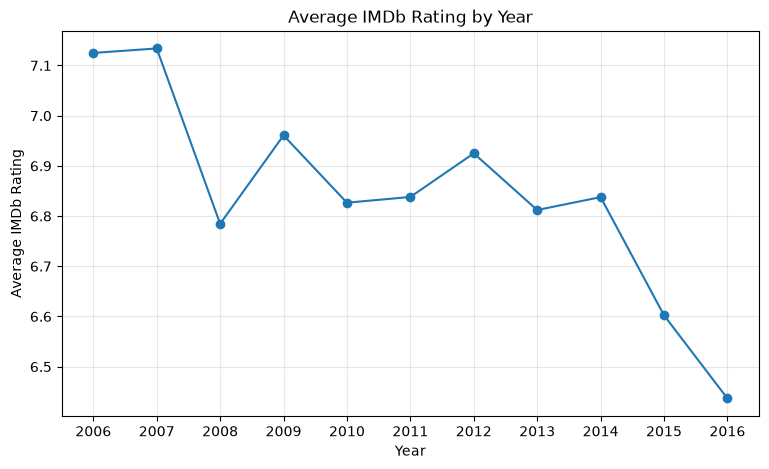

In [35]:
plt.figure(figsize=(9, 5))

plt.plot(yearly_rating.index, yearly_rating.values, marker="o")

plt.xlabel("Year")
plt.ylabel("Average IMDb Rating")
plt.title("Average IMDb Rating by Year")

plt.xticks(yearly_rating.index)
plt.grid(True, alpha=0.3)

plt.show()

In [36]:
revenue_rating_corr = revenue_df["Revenue (Millions)"].corr(
    revenue_df["Rating"]
)

revenue_rating_corr

np.float64(0.21765389419105996)

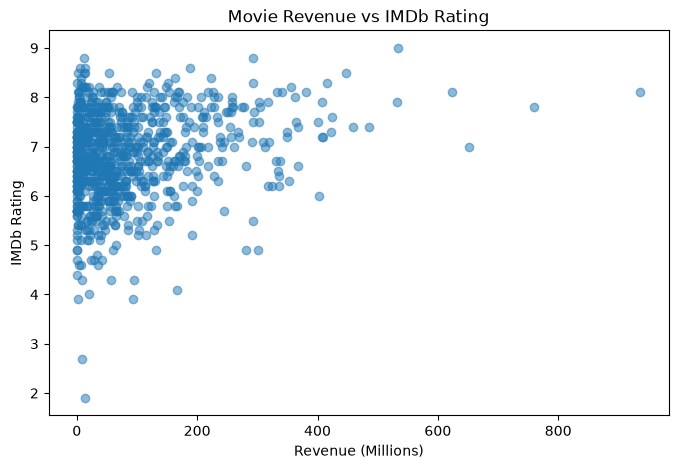

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(
    revenue_df["Revenue (Millions)"],
    revenue_df["Rating"],
    alpha=0.5
)

plt.xlabel("Revenue (Millions)")
plt.ylabel("IMDb Rating")
plt.title("Movie Revenue vs IMDb Rating")

plt.show()

In [38]:
df["Votes"].corr(df["Rating"])

np.float64(0.5115373197657556)

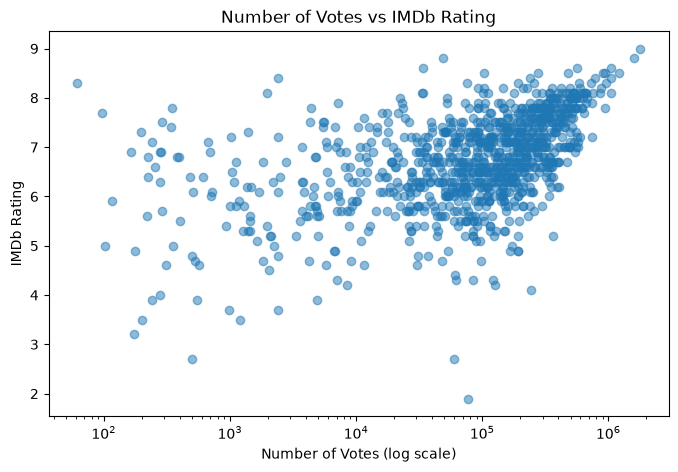

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Votes"], df["Rating"], alpha=0.5)

plt.xscale("log")

plt.xlabel("Number of Votes (log scale)")
plt.ylabel("IMDb Rating")
plt.title("Number of Votes vs IMDb Rating")

plt.show()

In [42]:
votes_revenue_corr = revenue_df["Votes"].corr(
    revenue_df["Revenue (Millions)"]
)

votes_revenue_corr

np.float64(0.6396613969323175)

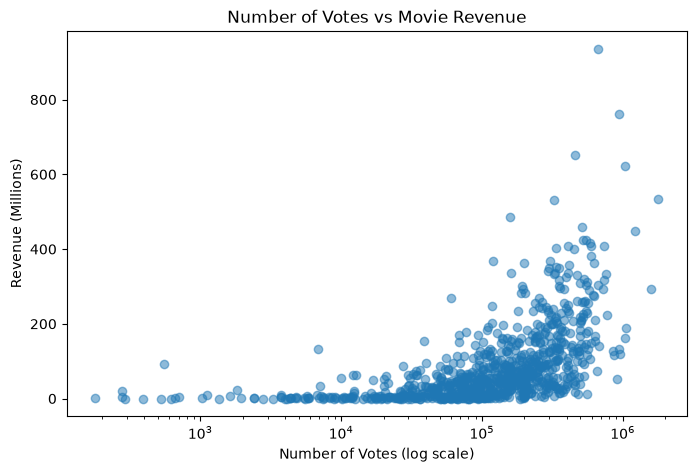

In [43]:
plt.figure(figsize=(8, 5))

plt.scatter(
    revenue_df["Votes"],
    revenue_df["Revenue (Millions)"],
    alpha=0.5
)

plt.xscale("log")

plt.xlabel("Number of Votes (log scale)")
plt.ylabel("Revenue (Millions)")
plt.title("Number of Votes vs Movie Revenue")

plt.show()

In [39]:
revenue_df["Votes"].corr(revenue_df["Revenue (Millions)"])

np.float64(0.6396613969323175)

In [40]:
df[["Title", "Year", "Genre", "Rating", "Votes"]].sort_values(
    "Rating", ascending=False
).head(10)

,Title,Year,Genre,Rating,Votes
54,The Dark Knight,2008,"Action,Crime,Drama",9.0,1791916
80,Inception,2010,"Action,Adventure,Sci-Fi",8.8,1583625
117,Dangal,2016,"Action,Biography,Drama",8.8,48969
36,Interstellar,2014,"Adventure,Drama,Sci-Fi",8.6,1047747
249,The Intouchables,2011,"Biography,Comedy,Drama",8.6,557965
96,Kimi no na wa,2016,"Animation,Drama,Fantasy",8.6,34110
64,The Prestige,2006,"Drama,Mystery,Sci-Fi",8.5,913152
99,The Departed,2006,"Crime,Drama,Thriller",8.5,937414
476,The Lives of Others,2006,"Drama,Thriller",8.5,278103
124,The Dark Knight Rises,2012,"Action,Thriller",8.5,1222645


In [44]:
top_10_movies = df[
    ["Title", "Year", "Genre", "Rating", "Votes"]
].sort_values(
    "Rating",
    ascending=False
).head(10)

top_10_movies

,Title,Year,Genre,Rating,Votes
54,The Dark Knight,2008,"Action,Crime,Drama",9.0,1791916
80,Inception,2010,"Action,Adventure,Sci-Fi",8.8,1583625
117,Dangal,2016,"Action,Biography,Drama",8.8,48969
36,Interstellar,2014,"Adventure,Drama,Sci-Fi",8.6,1047747
249,The Intouchables,2011,"Biography,Comedy,Drama",8.6,557965
96,Kimi no na wa,2016,"Animation,Drama,Fantasy",8.6,34110
64,The Prestige,2006,"Drama,Mystery,Sci-Fi",8.5,913152
99,The Departed,2006,"Crime,Drama,Thriller",8.5,937414
476,The Lives of Others,2006,"Drama,Thriller",8.5,278103
124,The Dark Knight Rises,2012,"Action,Thriller",8.5,1222645


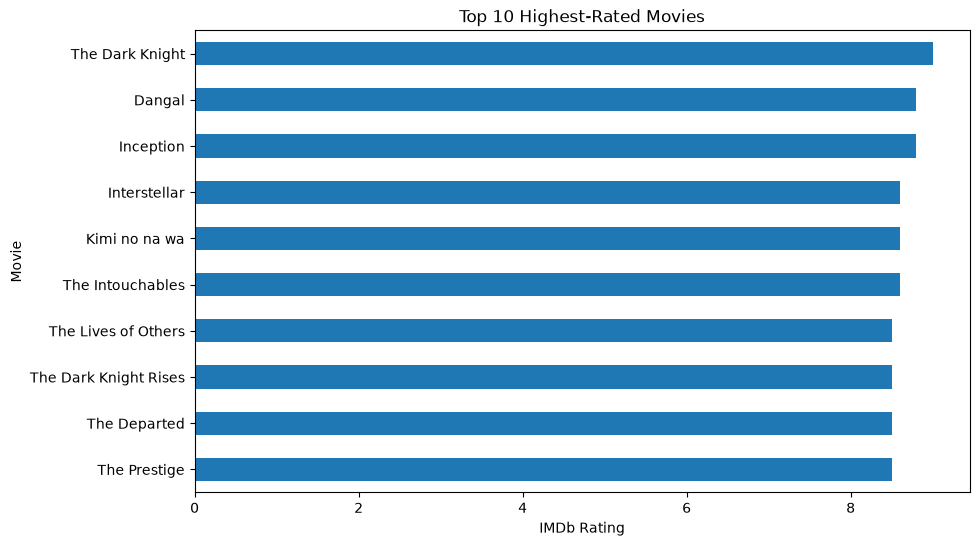

In [45]:
top_10_movies_sorted = top_10_movies.sort_values(
    "Rating",
    ascending=True
)

top_10_movies_sorted.plot(
    x="Title",
    y="Rating",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.xlabel("IMDb Rating")
plt.ylabel("Movie")
plt.title("Top 10 Highest-Rated Movies")
plt.show()

### Numerical Summary

Descriptive statistics were calculated to understand the distribution and range of the numerical variables.

In [46]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to identify patterns, relationships, and trends in the movie dataset.

The analysis focuses on:

1. Runtime and IMDb rating
2. Genre and IMDb rating
3. Ratings over time
4. Revenue and IMDb rating
5. Votes and IMDb rating
6. Votes and revenue
7. Highest-rated movies

In [47]:
print("Rating below 0:", (df["Rating"] < 0).sum())
print("Rating above 10:", (df["Rating"] > 10).sum())

print("Runtime below 0:", (df["Runtime (Minutes)"] < 0).sum())

print("Votes below 0:", (df["Votes"] < 0).sum())

print("Revenue below 0:", (df["Revenue (Millions)"] < 0).sum())

Rating below 0: 0
Rating above 10: 0
Runtime below 0: 0
Votes below 0: 0
Revenue below 0: 0


In [48]:
df[[
    "Year",
    "Runtime (Minutes)",
    "Rating",
    "Votes",
    "Revenue (Millions)",
    "Metascore"
]].isnull().sum()

Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

In [49]:
revenue_df = df.dropna(subset=["Revenue (Millions)"])

In [50]:
df.dtypes

Rank                    int64
Title                     str
Genre                     str
Description               str
Director                  str
Actors                    str
Year                    int64
Runtime (Minutes)       int64
Rating                float64
Votes                   int64
Revenue (Millions)    float64
Metascore             float64
dtype: object

### 3.1 Does Movie Runtime Relate to IMDb Rating?

**Question:** Is there a relationship between the duration of a movie and its IMDb rating?

A correlation coefficient is calculated first to measure the strength and direction of the linear relationship.

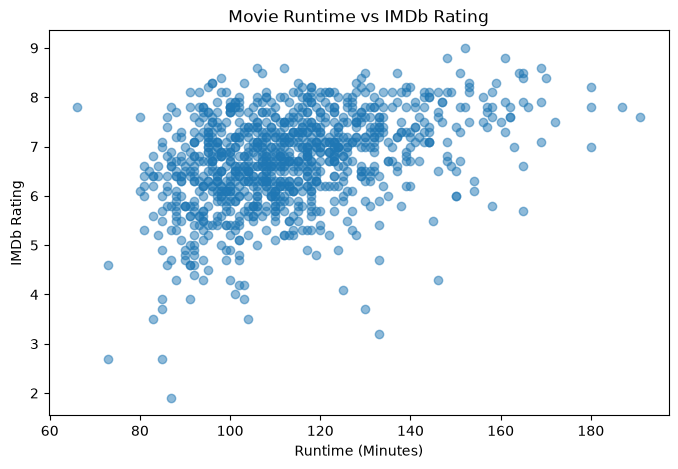

In [54]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Runtime (Minutes)"],
    df["Rating"],
    alpha=0.5
)

plt.xlabel("Runtime (Minutes)")
plt.ylabel("IMDb Rating")
plt.title("Movie Runtime vs IMDb Rating")

plt.savefig(
    "../visualizations/runtime_vs_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The correlation between movie runtime and IMDb rating is approximately **0.39**, indicating a moderate positive linear association in this dataset.

This suggests that longer movies tended to have somewhat higher IMDb ratings. However, the relationship is not strong enough to conclude that runtime alone determines movie ratings.

Correlation does not imply causation.

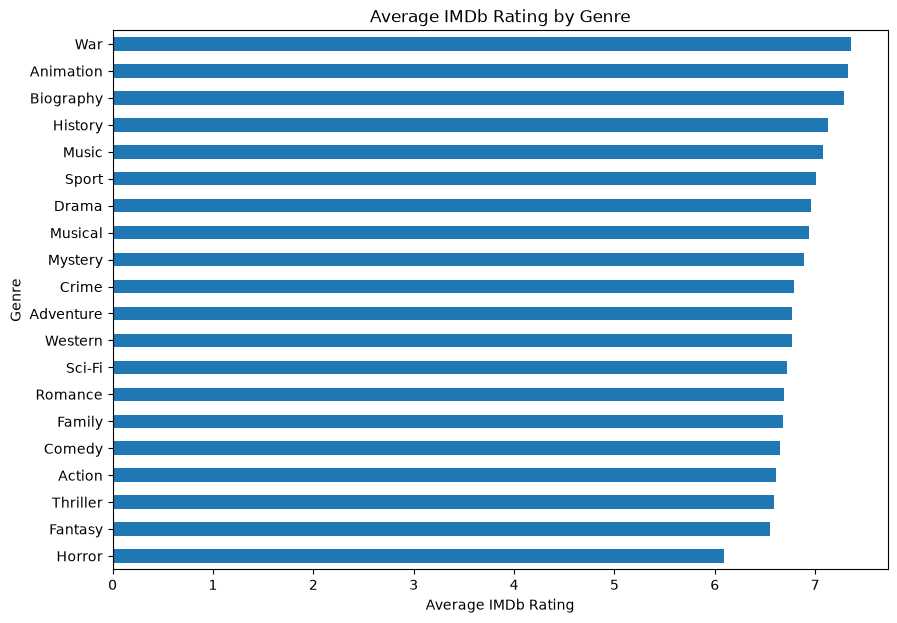

In [55]:
plt.figure(figsize=(10, 7))

genre_rating["mean"].sort_values().plot(
    kind="barh"
)

plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")
plt.title("Average IMDb Rating by Genre")

plt.savefig(
    "../visualizations/genre_vs_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.2 Which Genres Have the Highest Average IMDb Ratings?

**Question:** How do average IMDb ratings differ across movie genres?

Because some movies belong to multiple genres, the genre column is split so that each genre can be analyzed separately.

In [61]:
genre_df = df.copy()

genre_df["Genre"] = genre_df["Genre"].str.split(",")

genre_df = genre_df.explode("Genre")

genre_df["Genre"] = genre_df["Genre"].str.strip()

In [62]:
genre_rating = (
    genre_df.groupby("Genre")["Rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

genre_rating

,mean,count
Genre,,
War,7.353846,13
Animation,7.324490,49
Biography,7.290123,81
History,7.127586,29
Music,7.075000,16
Sport,7.011111,18
Drama,6.953801,513
Musical,6.940000,5
Mystery,6.886792,106


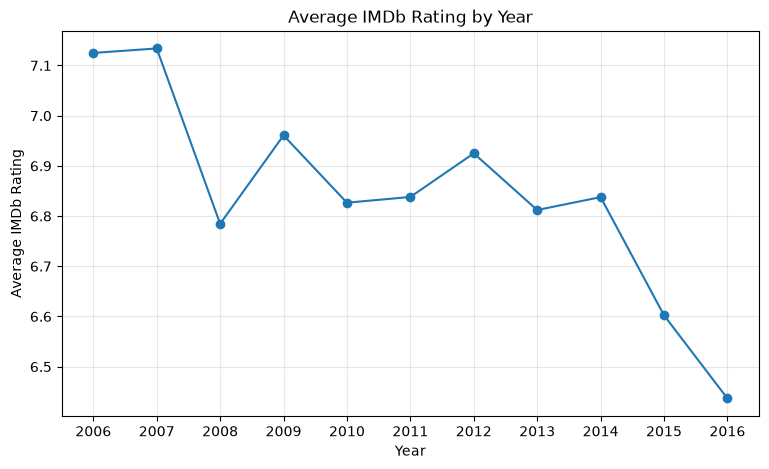

In [56]:
plt.figure(figsize=(9, 5))

plt.plot(
    yearly_rating.index,
    yearly_rating.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average IMDb Rating")
plt.title("Average IMDb Rating by Year")
plt.xticks(yearly_rating.index)
plt.grid(True, alpha=0.3)

plt.savefig(
    "../visualizations/rating_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Average IMDb ratings varied across the 2006–2016 period.

The dataset shows relatively higher average ratings around 2006–2007, followed by fluctuations and lower average ratings toward 2015–2016.

These results describe the movies included in this dataset and should not be interpreted as a measure of the overall quality of movies released during these years.

### Interpretation

War, Animation, and Biography had relatively high average IMDb ratings in this dataset.

However, the number of movies varies considerably between genres. Genres with very small sample sizes, such as Musical, Western, and War, should therefore be interpreted cautiously.

The results describe this dataset and do not imply that a particular genre inherently produces higher-rated movies.

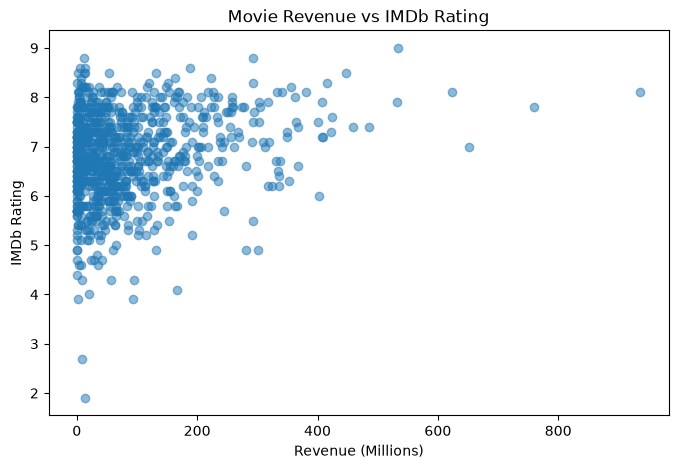

In [57]:
plt.figure(figsize=(8, 5))

plt.scatter(
    revenue_df["Revenue (Millions)"],
    revenue_df["Rating"],
    alpha=0.5
)

plt.xlabel("Revenue (Millions)")
plt.ylabel("IMDb Rating")
plt.title("Movie Revenue vs IMDb Rating")

plt.savefig(
    "../visualizations/revenue_vs_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

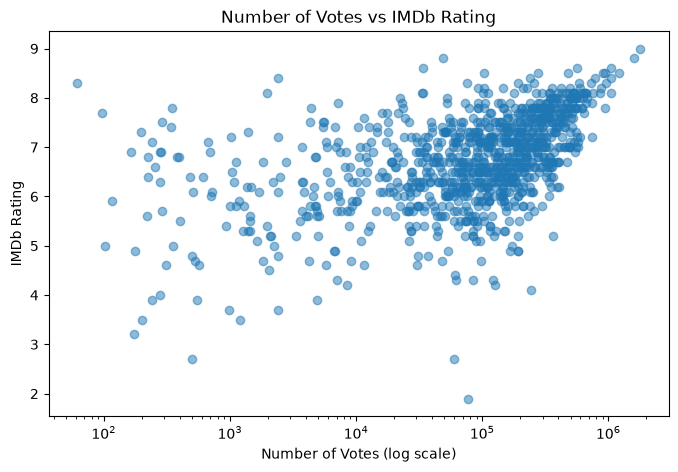

In [58]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Votes"],
    df["Rating"],
    alpha=0.5
)

plt.xscale("log")

plt.xlabel("Number of Votes (log scale)")
plt.ylabel("IMDb Rating")
plt.title("Number of Votes vs IMDb Rating")

plt.savefig(
    "../visualizations/votes_vs_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

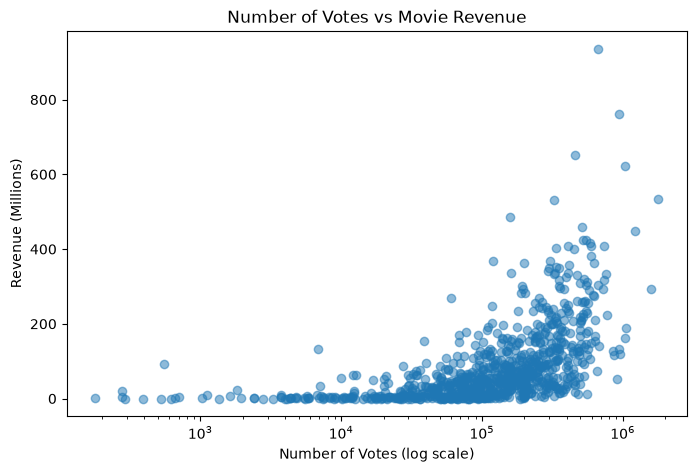

In [59]:
plt.figure(figsize=(8, 5))

plt.scatter(
    revenue_df["Votes"],
    revenue_df["Revenue (Millions)"],
    alpha=0.5
)

plt.xscale("log")

plt.xlabel("Number of Votes (log scale)")
plt.ylabel("Revenue (Millions)")
plt.title("Number of Votes vs Movie Revenue")

plt.savefig(
    "../visualizations/votes_vs_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

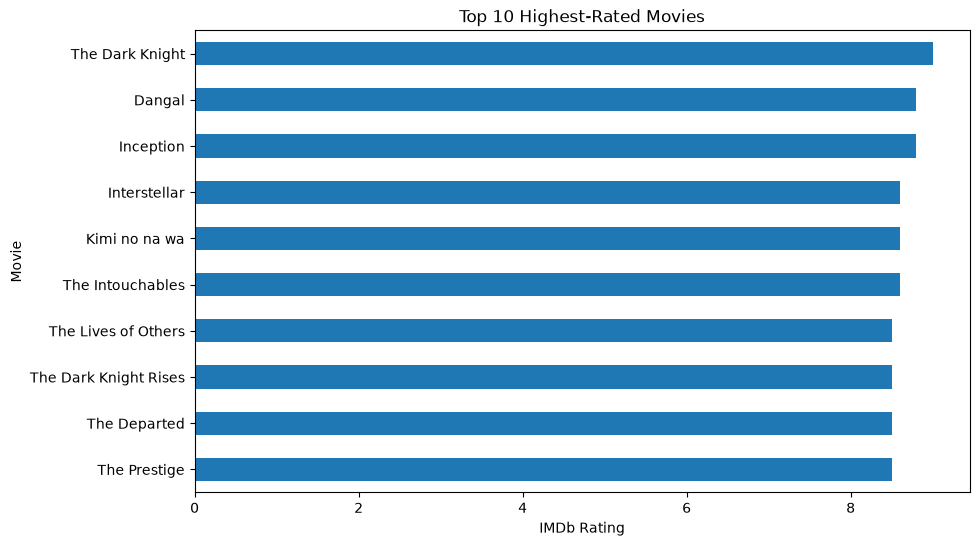

In [60]:
top_10_movies_sorted = top_10_movies.sort_values(
    "Rating",
    ascending=True
)

top_10_movies_sorted.plot(
    x="Title",
    y="Rating",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.xlabel("IMDb Rating")
plt.ylabel("Movie")
plt.title("Top 10 Highest-Rated Movies")

plt.savefig(
    "../visualizations/top_10_movies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The correlation between reported revenue and IMDb rating is approximately **0.22**, indicating a weak positive linear association in this dataset.

This suggests that movies with higher reported revenue tended to have somewhat higher IMDb ratings, but the relationship is relatively weak.

Revenue and IMDb rating should therefore not be treated as interchangeable measures of movie performance.

**Note:** Correlation does not imply causation.

In [63]:
yearly_rating = (
    df.groupby("Year")["Rating"]
    .mean()
    .sort_index()
)

yearly_rating

Year
2006    7.125000
2007    7.133962
2008    6.784615
2009    6.960784
2010    6.826667
2011    6.838095
2012    6.925000
2013    6.812088
2014    6.837755
2015    6.602362
2016    6.436700
Name: Rating, dtype: float64

### 3.3 How Have Average Movie Ratings Changed Over Time?

**Question:** How did the average IMDb rating of movies in this dataset vary between 2006 and 2016?

The yearly average rating is calculated to identify patterns and changes across the period.

In [65]:
revenue_rating_corr = revenue_df["Revenue (Millions)"].corr(
    revenue_df["Rating"]
)

revenue_rating_corr

np.float64(0.21765389419105996)

### 3.4 Is Movie Revenue Related to IMDb Rating?

**Question:** Is there a relationship between a movie's reported revenue and its IMDb rating?

Only movies with available revenue values are included in this analysis.

In [66]:
votes_rating_corr = df["Votes"].corr(
    df["Rating"]
)

votes_rating_corr

np.float64(0.5115373197657556)

### 3.5 Does Audience Engagement Relate to IMDb Rating?

**Question:** Is the number of audience votes associated with a movie's IMDb rating?

The number of votes can provide an indication of audience engagement, so we examine its relationship with IMDb rating.

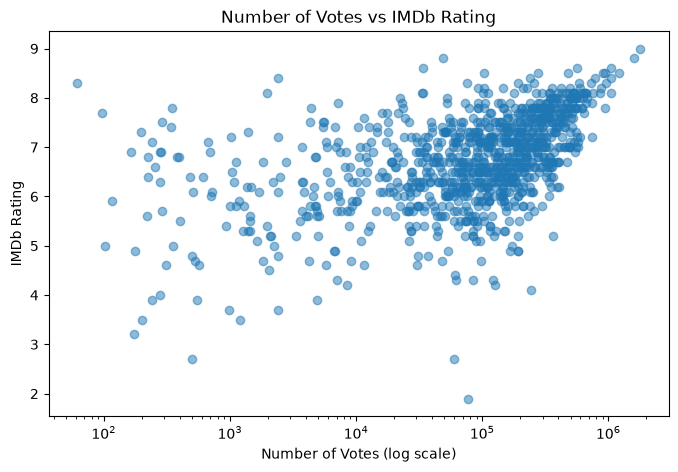

In [67]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Votes"],
    df["Rating"],
    alpha=0.5
)

plt.xscale("log")

plt.xlabel("Number of Votes (log scale)")
plt.ylabel("IMDb Rating")
plt.title("Number of Votes vs IMDb Rating")

plt.savefig(
    "../visualizations/votes_vs_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The correlation between the number of votes and IMDb rating is approximately **0.51**, indicating a moderate positive linear association in this dataset.

Movies with higher numbers of audience votes tended to have higher IMDb ratings. However, this relationship does not establish that receiving more votes causes a movie's rating to increase.

**Note:** Correlation does not imply causation.

In [68]:
votes_revenue_corr = revenue_df["Votes"].corr(
    revenue_df["Revenue (Millions)"]
)

votes_revenue_corr

np.float64(0.6396613969323175)

### 3.6 Does Audience Engagement Relate to Movie Revenue?

**Question:** Is the number of audience votes associated with a movie's reported revenue?

This analysis examines whether movies receiving more audience votes also tend to have higher reported revenue.

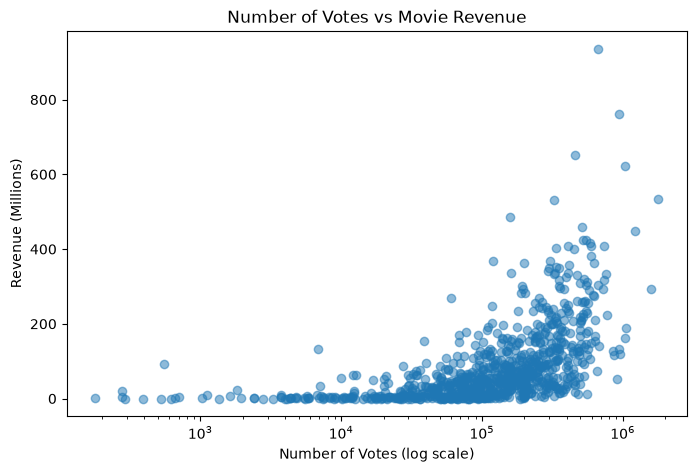

In [69]:
plt.figure(figsize=(8, 5))

plt.scatter(
    revenue_df["Votes"],
    revenue_df["Revenue (Millions)"],
    alpha=0.5
)

plt.xscale("log")

plt.xlabel("Number of Votes (log scale)")
plt.ylabel("Revenue (Millions)")
plt.title("Number of Votes vs Movie Revenue")

plt.savefig(
    "../visualizations/votes_vs_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The correlation between the number of votes and reported revenue is approximately **0.64**, indicating a fairly strong positive linear association in this dataset.

Movies with more audience votes tended to have higher reported revenue.

This relationship does not establish that audience votes cause higher revenue. Other factors, such as marketing, budget, popularity, and distribution, may also influence revenue.

**Note:** Correlation does not imply causation.

In [70]:
top_10_movies = df[
    ["Title", "Year", "Genre", "Rating", "Votes"]
].sort_values(
    "Rating",
    ascending=False
).head(10)

top_10_movies

,Title,Year,Genre,Rating,Votes
54,The Dark Knight,2008,"Action,Crime,Drama",9.0,1791916
80,Inception,2010,"Action,Adventure,Sci-Fi",8.8,1583625
117,Dangal,2016,"Action,Biography,Drama",8.8,48969
36,Interstellar,2014,"Adventure,Drama,Sci-Fi",8.6,1047747
249,The Intouchables,2011,"Biography,Comedy,Drama",8.6,557965
96,Kimi no na wa,2016,"Animation,Drama,Fantasy",8.6,34110
64,The Prestige,2006,"Drama,Mystery,Sci-Fi",8.5,913152
99,The Departed,2006,"Crime,Drama,Thriller",8.5,937414
476,The Lives of Others,2006,"Drama,Thriller",8.5,278103
124,The Dark Knight Rises,2012,"Action,Thriller",8.5,1222645


### 3.7 Which Movies Have the Highest IMDb Ratings?

**Question:** Which movies have the highest IMDb ratings in this dataset?

The top 10 movies are identified by sorting the dataset by IMDb rating in descending order.

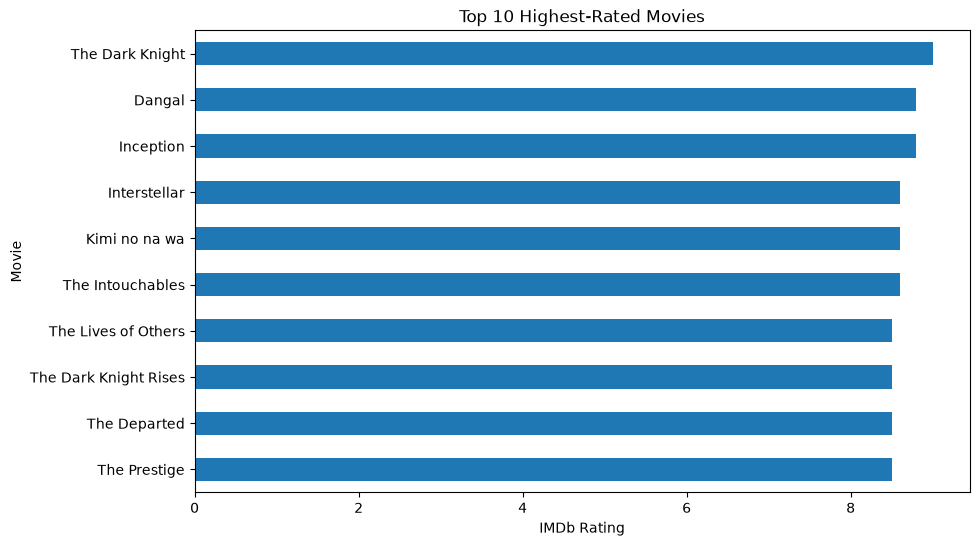

In [71]:
top_10_movies_sorted = top_10_movies.sort_values(
    "Rating",
    ascending=True
)

top_10_movies_sorted.plot(
    x="Title",
    y="Rating",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

plt.xlabel("IMDb Rating")
plt.ylabel("Movie")
plt.title("Top 10 Highest-Rated Movies")

plt.savefig(
    "../visualizations/top_10_movies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The analysis identifies the 10 highest-rated movies within this dataset.

The Dark Knight has the highest rating at 9.0, while the remaining movies in the top 10 have ratings between 8.5 and 8.8.

These rankings apply only to the movies included in this dataset and should not be interpreted as a ranking of all movies.

## 4. Key Insights

### 1. Runtime and IMDb Ratings
Movies with longer runtimes showed a positive association with IMDb ratings, with a correlation of approximately **0.39**. However, runtime alone does not strongly determine a movie's rating.

### 2. Genre and IMDb Ratings
War, Animation, and Biography had relatively high average IMDb ratings in this dataset. However, some of these genres have relatively small sample sizes, so their averages should be interpreted cautiously.

### 3. Ratings Over Time
Average IMDb ratings varied between 2006 and 2016. The dataset shows relatively higher average ratings around 2006–2007 and lower averages toward 2015–2016.

### 4. Revenue and IMDb Ratings
Reported revenue and IMDb rating had a weak positive correlation of approximately **0.22**. Higher-revenue movies were not necessarily much higher-rated.

### 5. Votes and IMDb Ratings
The number of audience votes had a moderate positive correlation with IMDb rating of approximately **0.51**. Movies with more votes tended to have higher ratings in this dataset.

### 6. Votes and Revenue
The number of votes had a stronger positive correlation with reported revenue of approximately **0.64**. Movies with more audience votes tended to have higher reported revenue.

### 7. Highest-Rated Movies
The Dark Knight had the highest IMDb rating in this dataset at **9.0**, followed by several movies rated between **8.5 and 8.8**.

> **Important:** Correlation measures association, not causation. These findings describe the relationships observed in this dataset and should not be interpreted as causal effects.

## 5. Conclusion

This analysis explored 1,000 movies from 2006–2016 to understand patterns in IMDb ratings, runtime, genre, revenue, audience votes, and release year.

The analysis found positive associations between IMDb ratings and both movie runtime and audience votes. Revenue had a weaker association with IMDb ratings, while the number of audience votes showed a stronger association with reported revenue.

Genre-level analysis also showed differences in average ratings, although genres with small sample sizes require cautious interpretation. Yearly analysis showed that average ratings varied throughout the period covered by the dataset.

Overall, the project demonstrates how exploratory data analysis can be used to identify patterns and relationships in movie data using Python, Pandas, Matplotlib, and statistical correlation.

### Limitations

- The dataset contains movies from a limited period (2006–2016).
- Revenue and Metascore contain missing values.
- Correlation does not establish causation.
- Genre sample sizes vary considerably.
- The findings describe this dataset and may not represent the entire movie industry.